In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
train=pd.read_csv("../input/titanic/train.csv")
test=pd.read_csv("../input/titanic/test.csv")

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [6]:
print(train.shape,test.shape)

(891, 12) (418, 11)


In [7]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<AxesSubplot:>

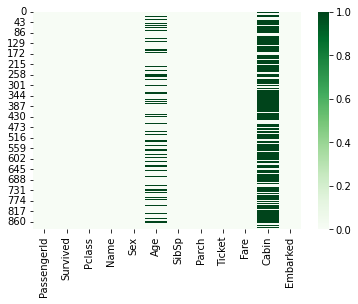

In [8]:
sns.heatmap(train.isnull(),cmap="Greens")

In [9]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
train["Embarked"].value_counts()


S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [11]:
def my_pipe(file):
  file = file.drop(["PassengerId","Name","Ticket","Fare","Cabin"],axis=1)
  file['Age'] = file["Age"].fillna(file['Age'].mean())
  file["Sex"]=file.Sex.map({"male":1,"female":0})
  file['Embarked'] = file['Embarked'].fillna('S')
  dummy = pd.get_dummies(file['Embarked'],drop_first=True)
  file.drop('Embarked',axis = 1 ,inplace=True)
  file = pd.concat([dummy , file],axis = 1 )
  return file



/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Survived', ylabel='count'>

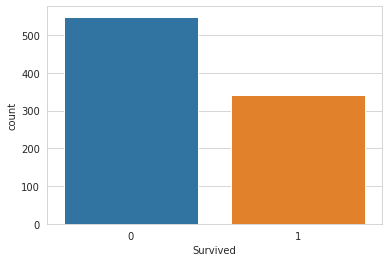

In [12]:
sns.set_style("whitegrid")
# sns.countplot(x='Survived',data=train)
# sns.countplot(train['Survived'])
sns.countplot(train.Survived)

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Sex', ylabel='count'>

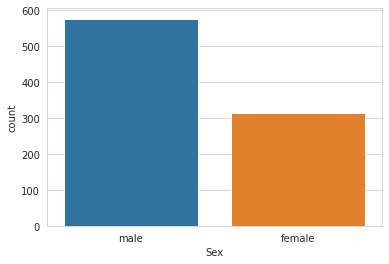

In [13]:
sns.countplot(train['Sex'])

<AxesSubplot:xlabel='Survived', ylabel='count'>

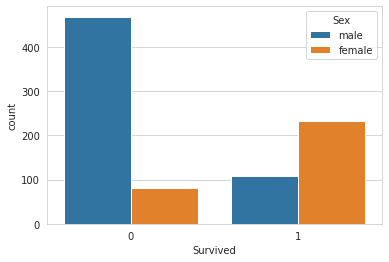

In [14]:
sns.countplot(x=train["Survived"],hue="Sex",data=train)
# sns.countplot(x="Survived",hue="Sex",data=train)

<AxesSubplot:xlabel='Pclass', ylabel='count'>

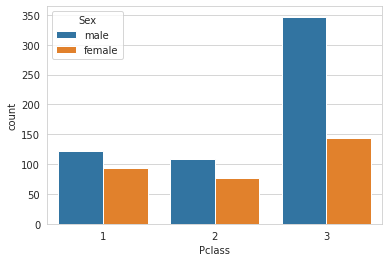

In [15]:
sns.countplot(x="Pclass",hue="Sex",data=train)

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Age', ylabel='Density'>

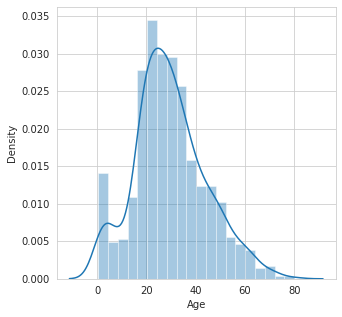

In [16]:
#train.hist("Age",bins=40)
#train["Age"].hist(bins=40)
plt.figure(figsize=(5,5))
# plt.hist(train["Age"],bins=40,color="red")
sns.distplot(train["Age"],kde=True)

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='SibSp', ylabel='count'>

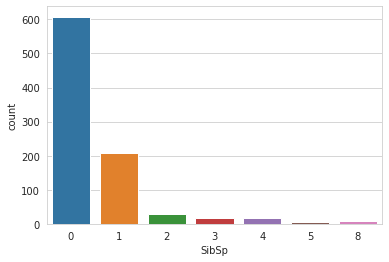

In [17]:
sns.countplot(train["SibSp"])

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Parch', ylabel='count'>

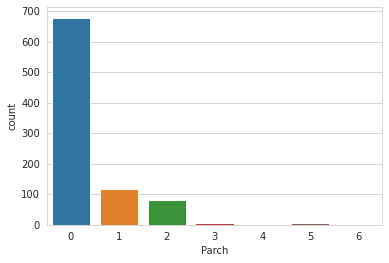

In [18]:
sns.countplot(train["Parch"])

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

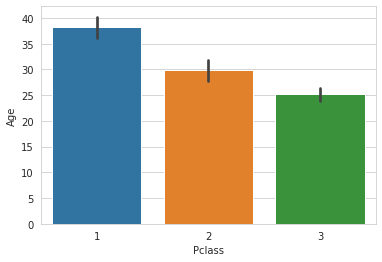

In [19]:
sns.barplot(x="Pclass",y="Age",data=train)

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

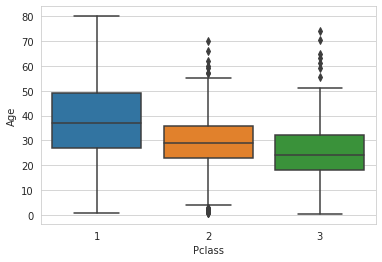

In [20]:
sns.boxplot(x="Pclass",y="Age",data=train)

In [21]:
train = my_pipe(train)
test = my_pipe(test)
train.head()

,Q,S,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,1,0,3,1,22.0,1,0
1,0,0,1,1,0,38.0,1,0
2,0,1,1,3,0,26.0,0,0
3,0,1,1,1,0,35.0,1,0
4,0,1,0,3,1,35.0,0,0


In [22]:
train.isnull().sum()

Q           0
S           0
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
dtype: int64

In [23]:
test.head()

,Q,S,Pclass,Sex,Age,SibSp,Parch
0,1,0,3,1,34.5,0,0
1,0,1,3,0,47.0,1,0
2,1,0,2,1,62.0,0,0
3,0,1,3,1,27.0,0,0
4,0,1,3,0,22.0,1,1


In [24]:
x=train.drop("Survived",axis=1)
y=train.Survived

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [26]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier()
tree.fit(x_train,y_train)
y_pred=tree.predict(x_test)

In [27]:
from sklearn.ensemble import RandomForestClassifier
forest=RandomForestClassifier()
forest.fit(x_train,y_train)
y_pred=forest.predict(x_test)

In [28]:
 print("accuracy of Decision tree model:", tree.score(x_train,y_train))
 print("accuracy of Random forest classifier model:", forest.score(x_train,y_train))

accuracy of Decision tree model: 0.9454253611556982
accuracy of Random forest classifier model: 0.9454253611556982


In [29]:
y_pred=forest.predict(test)

In [30]:
sub=pd.read_csv("../input/titanic/gender_submission.csv")
sub["Survived"]=y_pred

In [31]:
sub.to_csv("submission.csv",index=False)